In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/architsharma01/loan-approval-prediction-dataset/loan_approval_dataset.csv


In [2]:
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# from sklearn.composer import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(
accuracy_score,
precision_score,
recall_score,
classification_report,
confusion_matrix,
ConfusionMatrixDisplay,
roc_auc_score
)


In [3]:
df = pd.read_csv("/kaggle/input/datasets/architsharma01/loan-approval-prediction-dataset/loan_approval_dataset.csv")
df.head(5)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
print(df.shape)
df.info()

(4269, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [5]:
print("Null :",df.isnull().sum())
print("Duplicate :", df.duplicated().sum())

Null : loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64
Duplicate : 0


In [6]:
df.columns = df.columns.str.strip()

cat_cols = df.select_dtypes(include='object').columns
cat_cols = cat_cols[cat_cols != 'loan_status']
print("Categorical data:", cat_cols)
num_cols = df.select_dtypes(include='number').columns
print("numerical data:", num_cols)

Categorical data: Index(['education', 'self_employed'], dtype='object')
numerical data: Index(['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount',
       'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='object')


In [7]:
print("target class:",df['loan_status'].value_counts())
print("target percentage:",df['loan_status'].value_counts(normalize=True)*100)

target class: loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64
target percentage: loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64


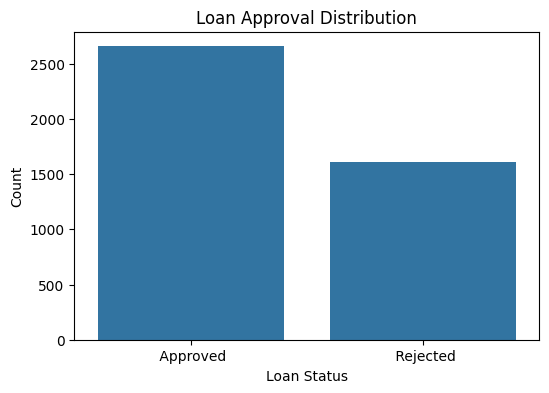

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='loan_status')

plt.title('Loan Approval Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

In [9]:
numerical_cols = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


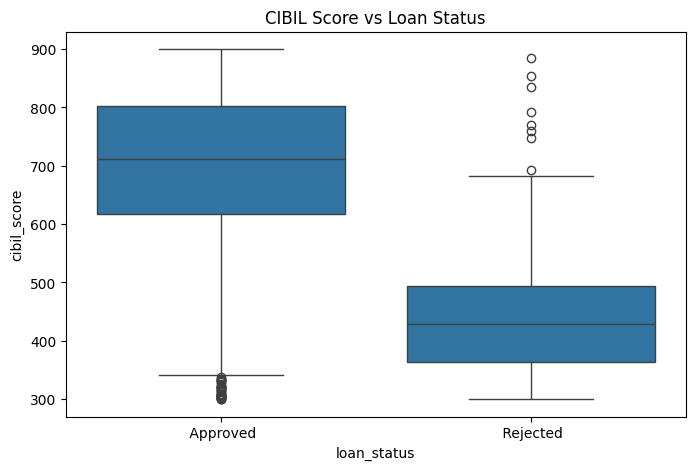

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='loan_status',
    y='cibil_score'
)

plt.title('CIBIL Score vs Loan Status')
plt.show()

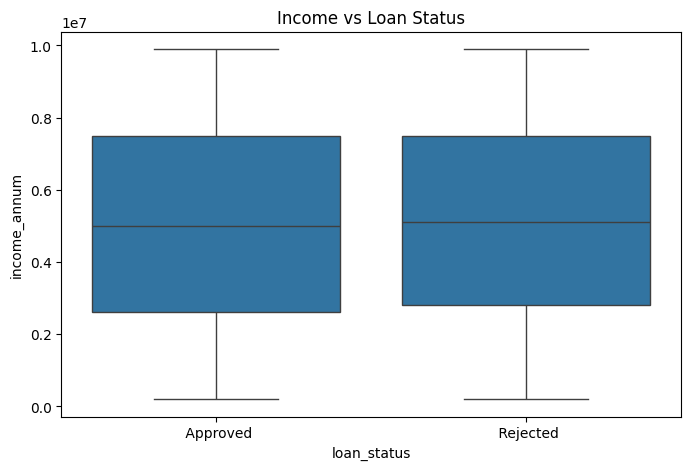

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='loan_status',
    y='income_annum'
)

plt.title('Income vs Loan Status')
plt.show()

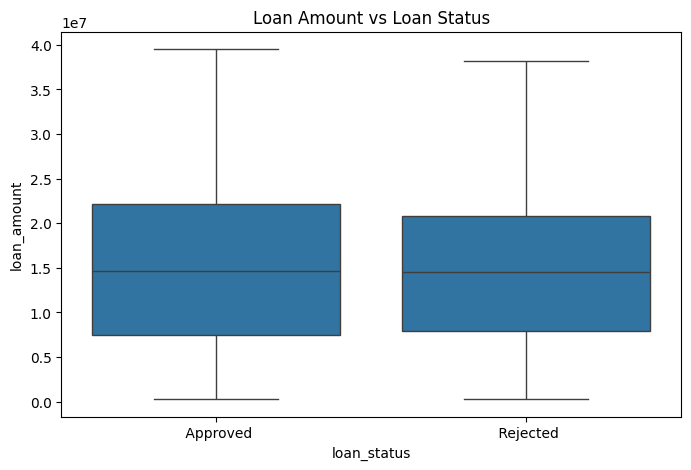

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='loan_status',
    y='loan_amount'
)

plt.title('Loan Amount vs Loan Status')
plt.show()

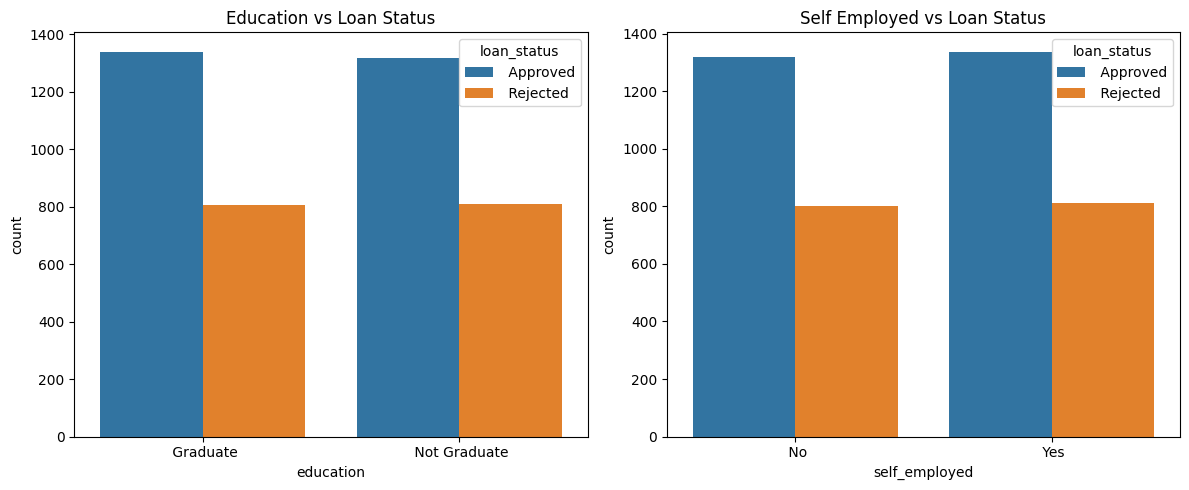

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(
    data=df,
    x='education',
    hue='loan_status',
    ax=axes[0]
)

axes[0].set_title('Education vs Loan Status')

sns.countplot(
    data=df,
    x='self_employed',
    hue='loan_status',
    ax=axes[1]
)

axes[1].set_title('Self Employed vs Loan Status')

plt.tight_layout()
plt.show()

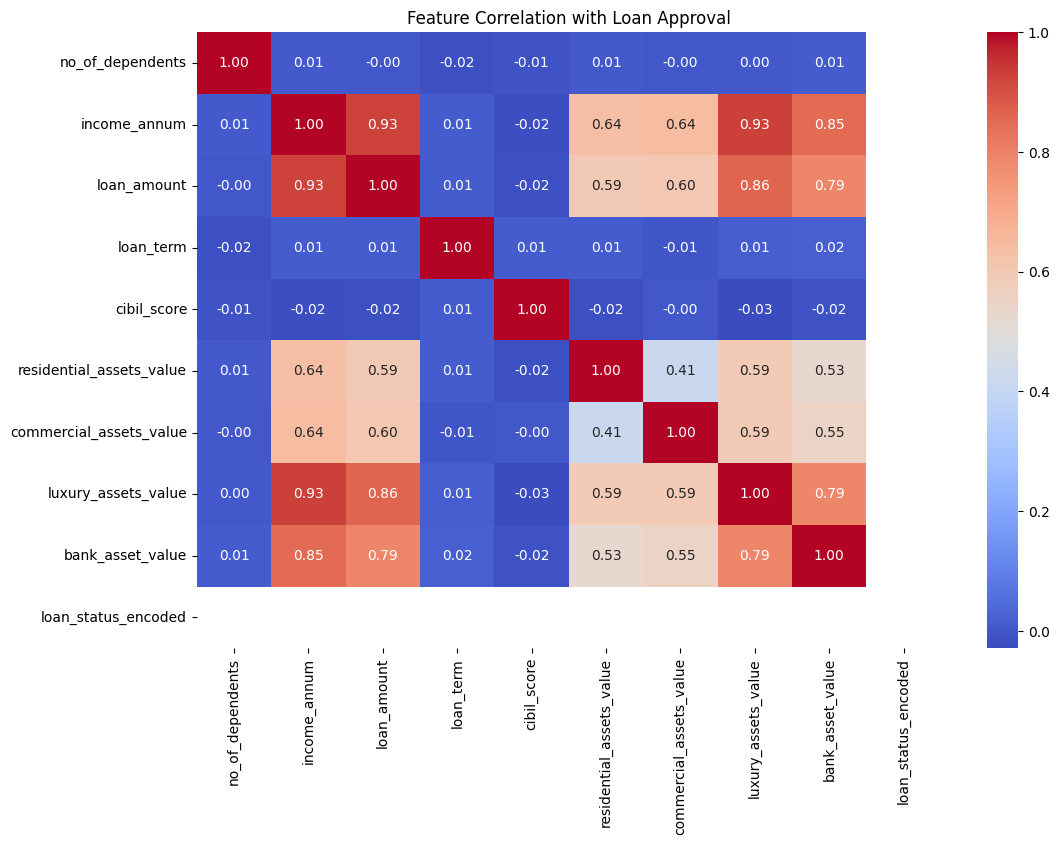

In [14]:
df_corr = df.copy()

df_corr['loan_status_encoded'] = (
    df_corr['loan_status']
    .map({'Rejected': 0, 'Approved': 1})
)

correlation = df_corr[numerical_cols + ['loan_status_encoded']].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Feature Correlation with Loan Approval')
plt.show()

In [15]:
df.groupby('loan_status')[[
    'income_annum',
    'loan_amount',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]].mean().round(0)

,income_annum,loan_amount,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
loan_status,,,,,,,
Approved,5025904.0,15247252.0,703.0,7399812.0,5001355.0,15016604.0,4959526.0
Rejected,5113825.0,14946063.0,429.0,7592498.0,4926720.0,15306944.0,5004960.0


In [16]:
pd.crosstab(
    df['education'],
    df['loan_status'],
    normalize='index'
).round(3) * 100

loan_status,Approved,Rejected
education,,
Graduate,62.5,37.5
Not Graduate,62.0,38.0


In [17]:
pd.crosstab(
    df['self_employed'],
    df['loan_status'],
    normalize='index'
).round(3) * 100

loan_status,Approved,Rejected
self_employed,,
No,62.2,37.8
Yes,62.2,37.8


In [18]:
pd.crosstab(
    df['loan_term'],
    df['loan_status'],
    normalize='index'
).round(3) * 100

loan_status,Approved,Rejected
loan_term,,
2,78.0,22.0
4,81.9,18.1
6,57.6,42.4
8,57.0,43.0
10,52.5,47.5
12,60.5,39.5
14,59.0,41.0
16,57.3,42.7
18,60.9,39.1


In [19]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['loan_status', 'loan_id'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Encode features
X_train['education'] = X_train['education'].str.strip().map({
    'Graduate': 1,
    'Not Graduate': 0
})

X_test['education'] = X_test['education'].str.strip().map({
    'Graduate': 1,
    'Not Graduate': 0
})

X_train['self_employed'] = X_train['self_employed'].str.strip().map({
    'Yes': 1,
    'No': 0
})

X_test['self_employed'] = X_test['self_employed'].str.strip().map({
    'Yes': 1,
    'No': 0
})

# Encode target
y_train = y_train.str.strip().map({
    'Approved': 1,
    'Rejected': 0
})

y_test = y_test.str.strip().map({
    'Approved': 1,
    'Rejected': 0
})

In [20]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

print(y_train.unique())
print(y_test.unique())

0
0
[0 1]
[1 0]


In [21]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8067915690866511
              precision    recall  f1-score   support

           0       0.82      0.62      0.71       323
           1       0.80      0.92      0.86       531

    accuracy                           0.81       854
   macro avg       0.81      0.77      0.78       854
weighted avg       0.81      0.81      0.80       854



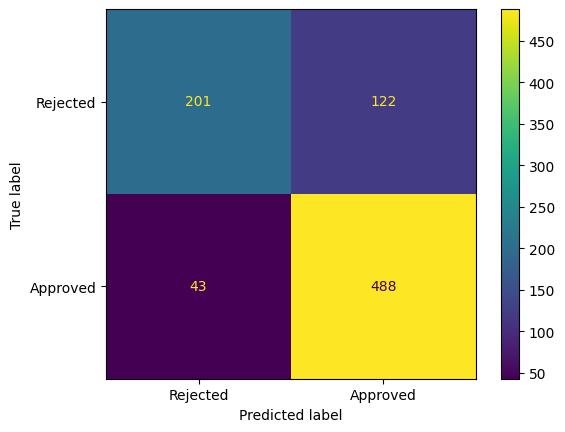

In [22]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Rejected', 'Approved']
).plot()

plt.show()

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LogisticRegression(max_iter=1000)

model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))

Accuracy: 0.9227166276346604
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       323
           1       0.93      0.95      0.94       531

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.92       854
weighted avg       0.92      0.92      0.92       854



In [24]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



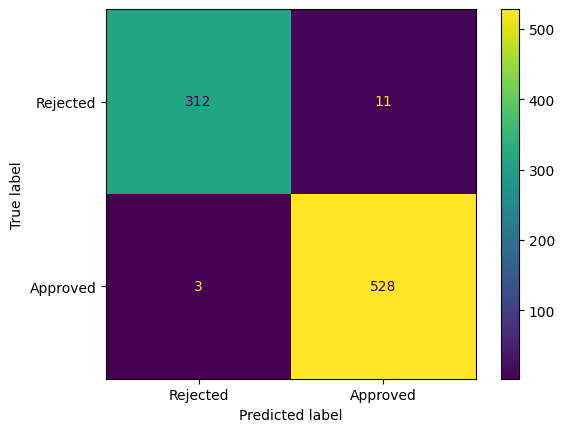

In [25]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Rejected', 'Approved']
).plot()

plt.show()

In [26]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.9980118125156693


In [27]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("CV ROC-AUC scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())

CV ROC-AUC scores: [0.99758322 0.99516644 0.99671683 0.99424533 0.99915185]
Mean CV ROC-AUC: 0.9965727314181487


In [28]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

cibil_score                 0.798269
loan_term                   0.064948
loan_amount                 0.031419
income_annum                0.020105
luxury_assets_value         0.019827
commercial_assets_value     0.018810
residential_assets_value    0.017395
bank_asset_value            0.015589
no_of_dependents            0.008549
self_employed               0.002733
education                   0.002357
dtype: float64


In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 200}
Best CV ROC-AUC: 0.9970569995440035


In [30]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       323
           1       0.98      1.00      0.99       531

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [31]:
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_prob_best))

Test ROC-AUC: 0.9974520881799046


[[312  11]
 [  2 529]]


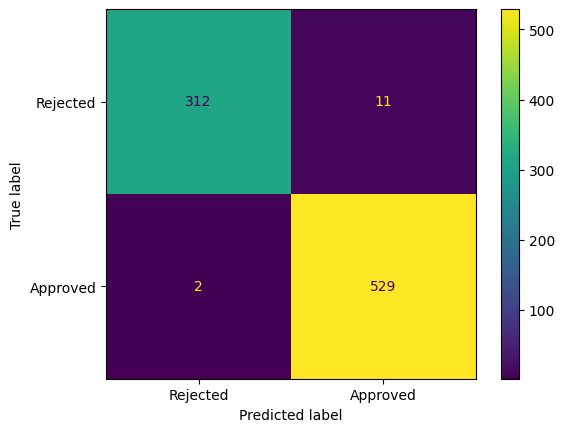

In [32]:
cm_best = confusion_matrix(y_test, y_pred_best)

print(cm_best)

ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=['Rejected', 'Approved']
).plot()

plt.show()